<a href="https://colab.research.google.com/github/Poorvi-M/Exam-Score-Predictor/blob/main/Exam_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Introduction**
This model is to predict the exam scores of a student based on certain parameters. The dataset used is from Kaggle. The methods that have been used are XGBBoost, Linear Regression, Ridge Regression, and Random Forest Regression.
Linear Regression and tuned XGBBoost gave the highest

#Step 1
**Import datasets and libraries**


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.
Path to dataset files: /kaggle/input/student-exam-performance-dataset-analysis


In [2]:
import pandas as pd
import numpy as np
import os
files = os.listdir(path)
print("Files found:", files)

df = pd.read_csv(path + "/" + files[0])  # path is already a variable from cell 1

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

print("Number of missing values:")
print(df.isnull().sum())
print("Column data types:")
print(df.dtypes)

Files found: ['StudentPerformanceFactors.csv']
Shape: (6607, 20)

Column names:
 ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

First 5 rows:
Number of missing values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity       

#Step 2
**Build a Pipeline**



In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('Exam_Score')
categorical_features= df.select_dtypes(include=['object']).columns
 # Correct way to chain steps in a pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first'))
])

preprocessor= ColumnTransformer(transformers=[('numeric', numeric_pipeline, numeric_features),('categorical', categorical_pipeline, categorical_features)])

#Step 3
**Try different models**

**XGB Regressor model**

In [4]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('xgb_regressor', XGBRegressor())])

param_grid= {
    "xgb_regressor__n_estimators" : [100, 200],
    "xgb_regressor__learning_rate" : [0.01, 0.1],
    "xgb_regressor__max_depth" : [3, 5]
}
grid_search=GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2'
)
grid_search.fit(X_train, y_train)
grid_search.predict(X_test)

array([65.01489 , 65.55646 , 71.12011 , ..., 66.104706, 65.06107 ,
       71.65047 ], dtype=float32)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
print(grid_search.best_params_)
print(grid_search.best_score_)
y_train_pred = grid_search.predict(X_train)
mse= mean_squared_error(y_train, y_train_pred)
r2= r2_score(y_train, y_train_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

{'xgb_regressor__learning_rate': 0.1, 'xgb_regressor__max_depth': 3, 'xgb_regressor__n_estimators': 200}
0.698736035823822
Mean Squared Error: 3.5360240936279297
R-squared: 0.7701038718223572


**Linear Regression Model**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('linear_regressor', LinearRegression())])
pipeline.fit(X_train, y_train)
y_pred=pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_train_pred= pipeline.predict(X_train)
mse= mean_squared_error(y_train, y_train_pred)
r2= r2_score(y_train, y_train_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 4.347985385795991
R-squared: 0.7173138373217006


**Ridge Regression Model**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('ridge_regressor', Ridge())])

# X_train and y_train only — test set stays sealed
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')

# cv=5 means your training data is split into 5 folds
# each fold takes a turn being the validation set
# so you get 5 R² scores — one per fold
print("Individual fold scores:", cv_scores)

# average across all 5 folds — this is your reliable estimate
print("Mean R²:", cv_scores.mean())

# std tells you how stable the model is across folds
print("Std:", cv_scores.std())


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid= {
    "ridge_regressor__alpha" : [0.01, 0.1, 1, 10, 100]
}
grid_search_cv=GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2'
)

In [ ]:
print(grid_search_cv.best_params_)
print(grid_search_cv.best_score_)
grid_search_cv.predict(X_test)
mse= mean_squared_error(y_train, y_train_pred)
r2= r2_score(y_train, y_train_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


In [5]:
grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

array(['numeric__Hours_Studied', 'numeric__Attendance',
       'numeric__Sleep_Hours', 'numeric__Previous_Scores',
       'numeric__Tutoring_Sessions', 'numeric__Physical_Activity',
       'categorical__Parental_Involvement_Low',
       'categorical__Parental_Involvement_Medium',
       'categorical__Access_to_Resources_Low',
       'categorical__Access_to_Resources_Medium',
       'categorical__Extracurricular_Activities_Yes',
       'categorical__Motivation_Level_Low',
       'categorical__Motivation_Level_Medium',
       'categorical__Internet_Access_Yes',
       'categorical__Family_Income_Low',
       'categorical__Family_Income_Medium',
       'categorical__Teacher_Quality_Low',
       'categorical__Teacher_Quality_Medium',
       'categorical__School_Type_Public',
       'categorical__Peer_Influence_Neutral',
       'categorical__Peer_Influence_Positive',
       'categorical__Learning_Disabilities_Yes',
       'categorical__Parental_Education_Level_High School',
       'categori

**Feature Engineering**

In [6]:
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
feature_importances_ = grid_search.best_estimator_.named_steps['xgb_regressor'].feature_importances_

df_features = pd.DataFrame({
    'features': feature_names,
    'importance': feature_importances_
}).sort_values(by='importance', ascending=False)

import matplotlib.pyplot as plt
import plotly.express as px

fig = px.bar(df_features, x='features', y='importance')
fig.show()

In [7]:
df = df_features[df_features['importance'] > 0.02]
print(df_features)

                                             features  importance
1                                 numeric__Attendance    0.253083
0                              numeric__Hours_Studied    0.096021
8                categorical__Access_to_Resources_Low    0.073230
9             categorical__Access_to_Resources_Medium    0.061898
7            categorical__Parental_Involvement_Medium    0.057084
6               categorical__Parental_Involvement_Low    0.052417
4                          numeric__Tutoring_Sessions    0.033926
3                            numeric__Previous_Scores    0.033708
23  categorical__Parental_Education_Level_Postgrad...    0.030805
20               categorical__Peer_Influence_Positive    0.029891
14                     categorical__Family_Income_Low    0.026556
10        categorical__Extracurricular_Activities_Yes    0.025714
25               categorical__Distance_from_Home_Near    0.025454
22  categorical__Parental_Education_Level_High School    0.022696
11        

In [8]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Re-load the original dataset to ensure 'df' has all original columns
# 'path' and 'files' variables are available from earlier cells
original_data_path = path + "/" + files[0]
df = pd.read_csv(original_data_path)

# Now, proceed with dropping the specified columns from the original dataset
df = df.drop(columns=['Gender', 'School_Type', 'Sleep_Hours', 'Physical_Activity', 'Distance_from_Home'])

X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('Exam_Score')
categorical_features = df.select_dtypes(include=['object']).columns
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor=ColumnTransformer(transformers=[('numeric', numeric_pipeline, numeric_features),('categorical', categorical_pipeline, categorical_features)])
pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('xgb_regressor', XGBRegressor())])

param_grid= {
    "xgb_regressor__n_estimators" : [100, 200],
    "xgb_regressor__learning_rate" : [0.01, 0.1],
    "xgb_regressor__max_depth" : [3, 5]
}
grid_search=GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2'
)
grid_search.fit(X_train, y_train)
grid_search.predict(X_test)

array([64.39885 , 65.94279 , 71.03275 , ..., 65.27632 , 65.106064,
       71.991394], dtype=float32)

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
grid_search.fit(X_train, y_train)
y_pred=grid_search.predict(X_test)
mse= mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
grid_search.predict(X_train)

Mean Squared Error: 3.6772992610931396
R-squared: 0.7398457527160645


array([68.18082, 69.63383, 67.49386, ..., 62.13745, 72.88229, 63.23647],
      dtype=float32)

In [ ]:
y_train_pred = grid_search.predict(X_train)
print(r2_score(y_train, y_train_pred))


0.7584143280982971


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('rf_regressor', RandomForestRegressor())])

param_grid= {
    "rf_regressor__n_estimators" : [100, 200, 300],
    "rf_regressor__min_samples_split" : [3, 5, 10],
    "rf_regressor__max_depth" : [2, 5, 10]
}
grid_search=GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2'
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)

In [ ]:
mse= mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
grid_search.predict(X_train)

Mean Squared Error: 5.60962459986238
R-squared: 0.6031414334411493


array([68.45686737, 68.5417497 , 69.22171778, ..., 62.7031883 ,
       69.35850974, 64.66453064])

In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'rf_regressor__max_depth': 10, 'rf_regressor__min_samples_split': 10, 'rf_regressor__n_estimators': 200}
0.6056738736290135


**Preddicted vs Actual Plot**

Text(0.5, 1.0, 'Actual vs Predicted')

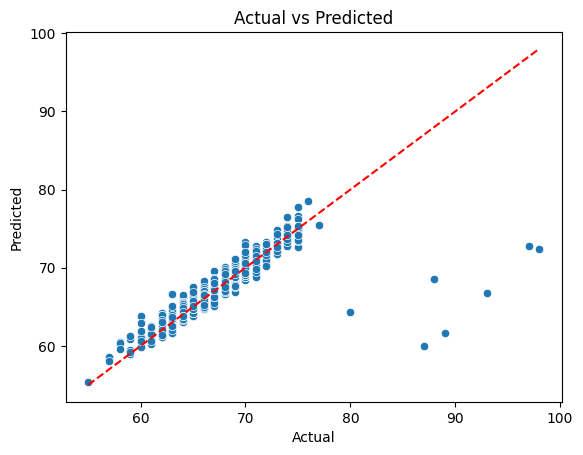

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

#**Conclusion**
The Linear Regression model and a tuned XGB Regressor model have the highest accuracy. The R² score was 0.77.

In [11]:
import joblib
joblib.dump(grid_search.best_estimator_, 'Exam Performance.pkl')

['Exam Performance.pkl']

In [12]:
from google.colab import files
files.download('Exam Performance.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>